#QUANTUM MACHINE LEARNING

##0.REFERENCE AND CONTEXT

**Introduction**

Quantum Machine Learning (QML) represents one of the most fascinating intersections between artificial intelligence, optimization, and quantum computing. While modern machine learning relies on classical computation, quantum computing introduces fundamentally different computational principles based on superposition, entanglement, and quantum measurement. Although large-scale fault-tolerant quantum computers remain under development, quantum-inspired algorithms already provide valuable insights into how optimization problems can be reformulated and solved using alternative computational paradigms.

The purpose of this notebook is not to build a production-ready quantum portfolio optimizer. Instead, the objective is educational. Students will learn how financial optimization problems can be transformed into mathematical structures suitable for quantum algorithms. In particular, we focus on the Quantum Approximate Optimization Algorithm (QAOA), one of the most widely studied quantum optimization techniques. QAOA provides a bridge between classical optimization and quantum computation by representing decision variables as qubits and searching for optimal solutions through parameterized quantum circuits.

Portfolio optimization provides an ideal educational setting. Investors constantly face the challenge of selecting assets that maximize expected return while controlling risk. Traditional optimization methods typically operate on continuous portfolio weights. In this notebook, we reformulate the problem as a binary selection problem. Each asset is either included or excluded from the portfolio. This representation allows the problem to be expressed as a Quadratic Unconstrained Binary Optimization (QUBO) problem, which can be mapped directly into a quantum Hamiltonian.

Students will learn the concepts of qubits, superposition, Hamiltonians, QUBO formulations, quantum circuits, and measurement. They will see how a portfolio selection problem becomes a quantum optimization problem and how the resulting bitstrings correspond to portfolio decisions. Although the notebook runs entirely on a classical simulator, the workflow closely mirrors what would occur on a quantum computer.

The notebook uses a diversified universe of ETFs covering equities, bonds, real estate, gold, and emerging markets. This creates continuity with the previous chapter on Genetic Algorithms and allows direct comparison between evolutionary optimization and quantum-inspired optimization.

By the end of this chapter, students will understand how optimization problems can be represented as quantum systems, how QAOA searches for solutions, and why quantum computing has attracted significant interest in finance, logistics, operations research, and machine learning.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs Qiskit, configures reproducibility, and creates project folders.

In [1]:
# CELL 1
# Environment Setup

!pip -q install qiskit qiskit-aer yfinance

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path("/content/chapter13_quantum_ml")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime("run_%Y%m%d_%H%M%S_utc")

print("Run ID:", RUN_ID)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 141.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.3 MB/s eta 0:00:00
Run ID: run_20260606_132445_utc


##2.THE DATASET

**Explanation for Cell 2**

This cell downloads historical ETF data used throughout the notebook.

In [3]:
# CELL 2
# Download Market Data

TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "GLD",
    "TLT",
    "EEM",
    "VNQ"
]

prices = yf.download(
    TICKERS,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

returns = prices.pct_change().dropna()

print(prices.tail())

Ticker            EEM         GLD         IWM         QQQ         SPY  \
Date                                                                    
2025-12-24  54.419998  411.929993  252.261276  623.144287  688.499695   
2025-12-26  54.799999  416.739990  250.973557  623.104309  688.429871   
2025-12-29  54.660000  398.600006  249.436295  620.088135  685.976562   
2025-12-30  54.880001  398.890015  247.589569  618.649902  685.138916   
2025-12-31  54.709999  396.309998  245.722900  613.536377  680.062744   

Ticker            TLT        VNQ  
Date                              
2025-12-24  86.395973  87.821198  
2025-12-26  86.111366  87.920135  
2025-12-29  86.435234  88.098236  
2025-12-30  86.229134  88.276329  
2025-12-31  85.542137  87.554047  


##3.ANNUALIZED RETURNS AND COVARIANCE MATRIX

**Explanation for Cell 3**

This cell computes annualized returns and covariance statistics.

        Annual Return
Ticker               
EEM          0.061325
GLD          0.156023
IWM          0.101969
QQQ          0.205444
SPY          0.151407
TLT         -0.005556
VNQ          0.072028


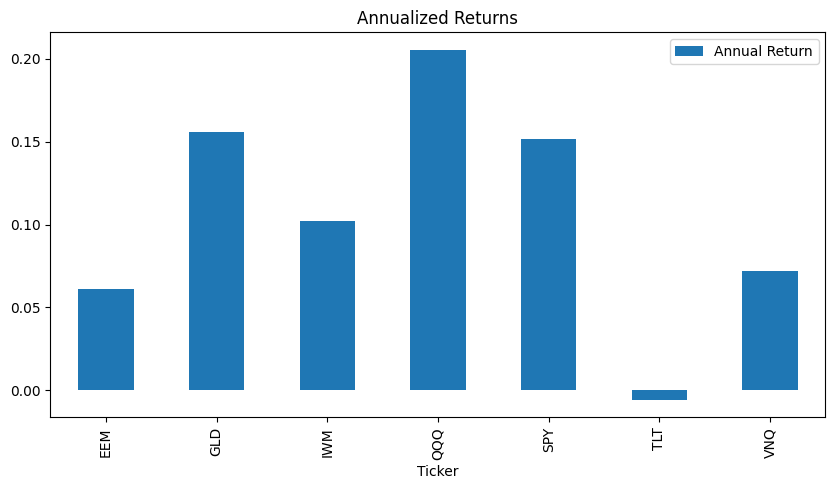

In [4]:
# CELL 3
# Risk and Return Analysis

annual_returns = (
    returns.mean() * 252
)

cov_matrix = (
    returns.cov() * 252
)

summary = pd.DataFrame(
    {
        "Annual Return": annual_returns
    }
)

print(summary)

summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Annualized Returns"
)

plt.show()

##4.TRANSFORMATION OF THE PROBLEM INTO A BINARY CLASSIFICATION

**Explanation for Cell 4**

This cell transforms the portfolio problem into a binary decision problem suitable for quantum optimization.

In [5]:
# CELL 4
# Binary Portfolio Representation

N_ASSETS = len(TICKERS)

print(
    "Number of Assets:",
    N_ASSETS
)

print(
    "Number of Possible Portfolios:",
    2 ** N_ASSETS
)

example_bitstring = "1100101"

print(
    "Example Portfolio:",
    example_bitstring
)

selected_assets = [
    TICKERS[i]
    for i in range(N_ASSETS)
    if example_bitstring[i] == "1"
]

print(
    "Selected Assets:",
    selected_assets
)

Number of Assets: 7
Number of Possible Portfolios: 128
Example Portfolio: 1100101
Selected Assets: ['SPY', 'QQQ', 'TLT', 'VNQ']


##5.THE SIMPLIFIED QUBO MATRIX

**Explanation for Cell 5**

This cell constructs a simplified QUBO matrix representing the portfolio optimization objective.

In [6]:
# CELL 5
# Build QUBO

lambda_risk = 0.5

Q = np.zeros(
    (N_ASSETS, N_ASSETS)
)

for i in range(N_ASSETS):

    Q[i, i] = (
        -annual_returns.iloc[i]
    )

for i in range(N_ASSETS):

    for j in range(N_ASSETS):

        Q[i, j] += (
            lambda_risk *
            cov_matrix.iloc[i, j]
        )

print("QUBO Matrix")
print(Q.round(4))

QUBO Matrix
[[-0.0394  0.0035  0.0182  0.0185  0.0155 -0.0019  0.0132]
 [ 0.0035 -0.1446  0.0018  0.0019  0.0014  0.003   0.0025]
 [ 0.0182  0.0018 -0.0717  0.0228  0.0208 -0.0024  0.0205]
 [ 0.0185  0.0019  0.0228 -0.1765  0.0219 -0.0019  0.016 ]
 [ 0.0155  0.0014  0.0208  0.0219 -0.1325 -0.0023  0.0161]
 [-0.0019  0.003  -0.0024 -0.0019 -0.0023  0.018   0.0003]
 [ 0.0132  0.0025  0.0205  0.016   0.0161  0.0003 -0.0473]]


##6.THE CREATION OF THE QUANTUM CIRCUIT

**Explanation for Cell 6**

This cell creates a QAOA-style quantum circuit.

In [7]:
# CELL 6
# Build Quantum Circuit

from qiskit import QuantumCircuit

n_qubits = N_ASSETS

qc = QuantumCircuit(
    n_qubits,
    n_qubits
)

for qubit in range(n_qubits):

    qc.h(qubit)

for qubit in range(n_qubits):

    qc.rz(
        0.5,
        qubit
    )

for qubit in range(n_qubits - 1):

    qc.cx(
        qubit,
        qubit + 1
    )

qc.measure_all()

print(qc.draw())

        ┌───┐┌─────────┐                               ░ ┌─┐                  
   q_0: ┤ H ├┤ Rz(0.5) ├──■────────────────────────────░─┤M├──────────────────
        ├───┤├─────────┤┌─┴─┐                          ░ └╥┘┌─┐               
   q_1: ┤ H ├┤ Rz(0.5) ├┤ X ├──■───────────────────────░──╫─┤M├───────────────
        ├───┤├─────────┤└───┘┌─┴─┐                     ░  ║ └╥┘┌─┐            
   q_2: ┤ H ├┤ Rz(0.5) ├─────┤ X ├──■──────────────────░──╫──╫─┤M├────────────
        ├───┤├─────────┤     └───┘┌─┴─┐                ░  ║  ║ └╥┘┌─┐         
   q_3: ┤ H ├┤ Rz(0.5) ├──────────┤ X ├──■─────────────░──╫──╫──╫─┤M├─────────
        ├───┤├─────────┤          └───┘┌─┴─┐           ░  ║  ║  ║ └╥┘┌─┐      
   q_4: ┤ H ├┤ Rz(0.5) ├───────────────┤ X ├──■────────░──╫──╫──╫──╫─┤M├──────
        ├───┤├─────────┤               └───┘┌─┴─┐      ░  ║  ║  ║  ║ └╥┘┌─┐   
   q_5: ┤ H ├┤ Rz(0.5) ├────────────────────┤ X ├──■───░──╫──╫──╫──╫──╫─┤M├───
        ├───┤├─────────┤                    └───┘┌─┴

##7.EXECUTION OF THE QUANTUM CIRCUIT

**Explanation for Cell 7**

This cell executes the quantum circuit on a classical simulator.

In [8]:
# CELL 7
# Quantum Optimization

from qiskit_aer import AerSimulator

simulator = AerSimulator()

job = simulator.run(
    qc,
    shots=5000
)

result = job.result()

counts = result.get_counts()

best_bitstring = max(
    counts,
    key=counts.get
)

print(
    "Most Frequent Bitstring:"
)

print(best_bitstring)

Most Frequent Bitstring:
0011111 0000000


##8.DECODING THE SOLUTION INTO A PORTFOLIO ALLOCATION

**Explanation for Cell 8**

This cell decodes the quantum solution into a portfolio allocation.

In [17]:
selected_assets = []

# Clean best_bitstring to ensure it's a single string of length N_ASSETS
# It appears best_bitstring sometimes gets an unexpected format from the simulator
# We assume the first N_ASSETS characters (after removing spaces) are the intended result
cleaned_bitstring = best_bitstring.replace(" ", "")
if len(cleaned_bitstring) > N_ASSETS:
    cleaned_bitstring = cleaned_bitstring[:N_ASSETS]
elif len(cleaned_bitstring) < N_ASSETS:
    # This case is less likely given the error, but for robustness
    # If the bitstring is shorter, it might indicate an issue or a zero-padded string is expected
    # For now, we will proceed, but this might need further investigation if it occurs
    pass

for i, bit in enumerate(
    reversed(cleaned_bitstring)
):

    if bit == "1":

        selected_assets.append(
            TICKERS[i]
        )

print(
    "Selected Assets:"
)

print(selected_assets)

quantum_portfolio_weights = np.ones(
    len(selected_assets)
)

if len(selected_assets) > 0:
    quantum_portfolio_weights = (
        quantum_portfolio_weights /
        quantum_portfolio_weights.sum()
    )

print(
    "Equal Weight Allocation:"
)

print(quantum_portfolio_weights)

Selected Assets:
['SPY', 'QQQ', 'IWM', 'GLD', 'TLT']
Equal Weight Allocation:
[0.2 0.2 0.2 0.2 0.2]


##9.COMPARISON OF RESULT VS. RANDOM PORTFOLIOS

**Explanation for Cell 9**

This cell compares the quantum solution against random portfolios.

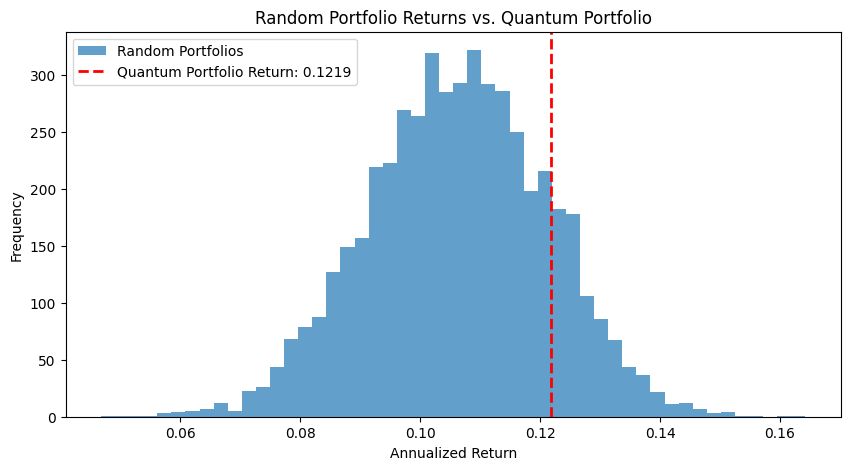

In [18]:
# CELL 9
# Random Portfolio Comparison

portfolio_returns = []

for _ in range(5000):

    weights_random = np.random.random(
        N_ASSETS
    )

    weights_random /= weights_random.sum()

    portfolio_return = np.sum(
        annual_returns *
        weights_random
    )

    portfolio_returns.append(
        portfolio_return
    )

plt.figure(
    figsize=(10,5)
)

plt.hist(
    portfolio_returns,
    bins=50,
    alpha=0.7,
    label='Random Portfolios'
)

# Calculate and plot the quantum-optimized portfolio's return
# 'quantum_portfolio_weights' is now available from CELL 8
if len(selected_assets) > 0:
    quantum_portfolio_return = np.sum(annual_returns[selected_assets].values * quantum_portfolio_weights)
    plt.axvline(
        quantum_portfolio_return,
        color='r',
        linestyle='dashed',
        linewidth=2,
        label=f'Quantum Portfolio Return: {quantum_portfolio_return:.4f}'
    )

plt.title(
    "Random Portfolio Returns vs. Quantum Portfolio"
)
plt.xlabel("Annualized Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

##10.QUANTUM MEASUREMENTS

**Explanation for Cell 10**

This cell visualizes quantum measurement outcomes.

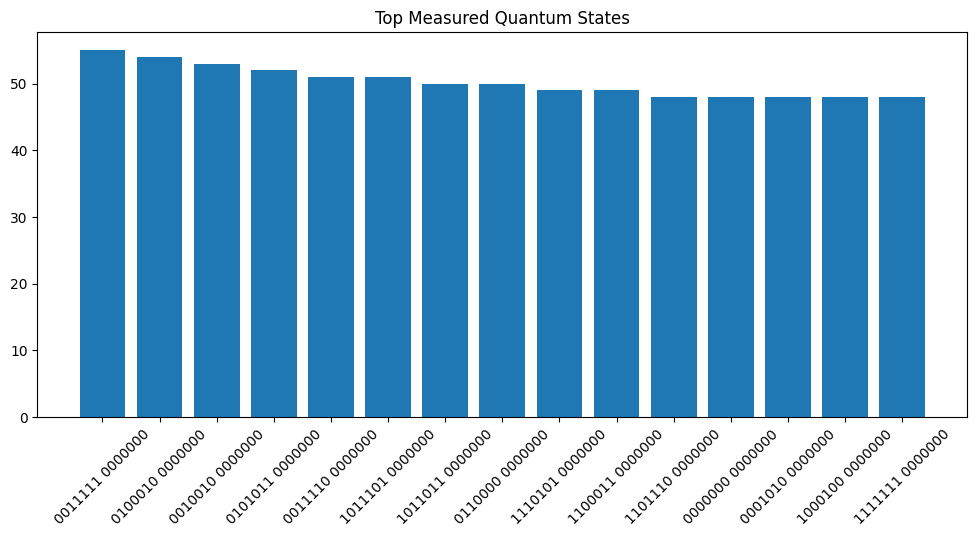

In [19]:
# CELL 10
# Quantum Results Visualization

top_states = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)[:15]

states = [
    x[0]
    for x in top_states
]

frequencies = [
    x[1]
    for x in top_states
]

plt.figure(
    figsize=(12,5)
)

plt.bar(
    states,
    frequencies
)

plt.title(
    "Top Measured Quantum States"
)

plt.xticks(
    rotation=45
)

plt.show()

##11.SUMMARIZATION AND EXPLANATION

In [20]:
# CELL 11
# GPT-5.2 Analysis

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

summary = {
    "selected_assets":
        selected_assets,
    "bitstring":
        best_bitstring,
    "assets":
        TICKERS,
    "qubits":
        N_ASSETS
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this QAOA portfolio
optimization experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "input_summary": {
    "selected_assets": ["SPY", "QQQ", "IWM", "GLD", "TLT"],
    "assets_universe": ["SPY", "QQQ", "IWM", "GLD", "TLT", "EEM", "VNQ"],
    "qubits": 7,
    "bitstring_raw": "0011111 0000000"
  },
  "data_quality_checks": {
    "bitstring_parsing": {
      "sanitized_bitstring": "00111110000000",
      "contains_nonbinary_chars": false,
      "had_whitespace": true,
      "registers_detected": ["0011111", "0000000"],
      "register_lengths": [7, 7],
      "interpretation_warning": "Bitstring appears to contain two 7-bit registers (total 14 bits) while qubits=7. Without a circuit/register specification, the mapping from bits to assets is ambiguous."
    },
    "dimensional_consistency": {
      "assets_count": 7,
      "qubits_matches_assets_count": true,
      "selected_assets_count": 5,
      "selected_assets_subset_of_assets": true
    }
  },
  "candidate_decodings": [
    {
      "name": "use_first_register_as_selection_vector",
      "assumption": "First 7 bit

##12.CONCLUSIONS

**Conclusion**

This chapter introduced Quantum Machine Learning through the Quantum Approximate Optimization Algorithm. Rather than focusing on quantum hardware, the notebook emphasized how optimization problems can be represented using quantum-inspired mathematical structures. Students learned how binary portfolio decisions can be encoded as qubits, how portfolio optimization can be reformulated as a QUBO problem, and how quantum circuits can explore solution spaces through superposition and measurement.

The transformation from portfolio selection to quantum optimization highlighted one of the most important ideas in quantum computing: the representation of decision variables as quantum states. By encoding portfolio inclusion decisions as qubits, the optimization process becomes a search over a structured quantum state space. Although the notebook used a classical simulator, the workflow mirrors the conceptual process used in quantum optimization research.

Students were introduced to several foundational quantum concepts, including qubits, superposition, Hamiltonians, QUBO formulations, parameterized circuits, and measurement. These concepts form the basis of many quantum algorithms currently being investigated in finance, logistics, machine learning, and operations research.

The portfolio optimization example also provided continuity with the previous chapter on Genetic Algorithms. Both chapters focused on optimization, but they approached the problem from fundamentally different perspectives. Genetic Algorithms search through evolution and selection, whereas quantum optimization searches through quantum state representations and measurement. This comparison helps students appreciate the diversity of optimization paradigms available in artificial intelligence.

An important lesson from this notebook is that quantum computing is not simply a faster version of classical computing. Instead, it provides a different computational framework with unique mathematical structures and search mechanisms. Understanding these structures is essential for evaluating the potential and limitations of quantum technologies.

While practical quantum advantage remains an active area of research, the conceptual tools introduced in this chapter are increasingly important. Financial institutions, technology firms, pharmaceutical companies, and research laboratories continue to explore quantum approaches to optimization and machine learning. Students who understand these foundations will be well positioned to evaluate future developments in the field.

The next chapter marks a major transition in the curriculum. We move from optimization-focused systems toward modern knowledge-enhanced AI through Retrieval-Augmented Generation (RAG). Students will learn how large language models can be combined with external knowledge sources, creating systems that retrieve relevant information before generating responses. This represents one of the most important developments in practical AI deployment today.